<a href="https://colab.research.google.com/github/samikshap515/231A044_NLP-EXPERIMENTS/blob/main/AIDS_Sem7_NLP_Experiment02/NLP_EXP_NO_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
import matplotlib.pyplot as plt
import random

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [ ]:
import nltk
from nltk.corpus import twitter_samples

In [ ]:
#load
tweets = twitter_samples.strings()
type(tweets)

list

In [ ]:
len(tweets)

30000

In [ ]:
import pandas as pd
all_tweets=pd.DataFrame(tweets,columns=["Tweets"])
all_tweets.head()

,Tweets
0,hopeless for tmr :(
1,Everything in the kids section of IKEA is so c...
2,@Hegelbon That heart sliding into the waste ba...
3,"“@ketchBurning: I hate Japanese call him ""bani..."
4,"Dang starting next week I have ""work"" :("


In [ ]:
#print
print("length of the first tweet:", len(tweets[2]))

length of the first tweet: 54


In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
positive_tweets=twitter_samples.strings('positive_tweets.json')
negative_tweets=twitter_samples.strings('negative_tweets.json')

In [ ]:
negative_tweets[1]

"Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :("

In [ ]:
import pandas as pd
positive_tweets=pd.DataFrame(positive_tweets,columns=["Tweets"])
positive_tweets["Sentiment"]="Positive"

In [ ]:
positive_tweets.head()

,Tweets,Sentiment
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,Positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,Positive
2,@DespiteOfficial we had a listen last night :)...,Positive
3,@97sides CONGRATS :),Positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,Positive


In [ ]:
negative_tweets=pd.DataFrame(negative_tweets,columns=["Tweets"])
negative_tweets["Sentiment"]="Negative"

In [ ]:
negative_tweets.head()

,Tweets,Sentiment
0,hopeless for tmr :(,Negative
1,Everything in the kids section of IKEA is so c...,Negative
2,@Hegelbon That heart sliding into the waste ba...,Negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",Negative
4,"Dang starting next week I have ""work"" :(",Negative


In [ ]:
tweets=pd.concat([positive_tweets,negative_tweets], ignore_index=True)
tweets = tweets.sample(frac=1).reset_index(drop=True)
tweets

,Tweets,Sentiment
0,I.M's voice :( lord help,Negative
1,@Vladimir_EShop @VladimirBank thanks :),Positive
2,@crushinghes the summer holidays are great but...,Negative
3,@Swift__Girl Agreed. Suspicious Minds :),Positive
4,@kaisoography very good read promise :(,Negative
...,...,...
9995,I have Ariana grande Selena Gomez Louis tomlin...,Positive
9996,i went in the sea and now have a massive fucki...,Negative
9997,"@DADDYNAMJ00N @bbydesu No~ I mean, that @bbyde...",Negative
9998,gooodnight i love all the boys and iv ris zoe ...,Positive


In [ ]:
print('number of positive tweets: ', len(positive_tweets))
print('number of negative tweets: ', len(negative_tweets))

number of positive tweets:  5000
number of negative tweets:  5000


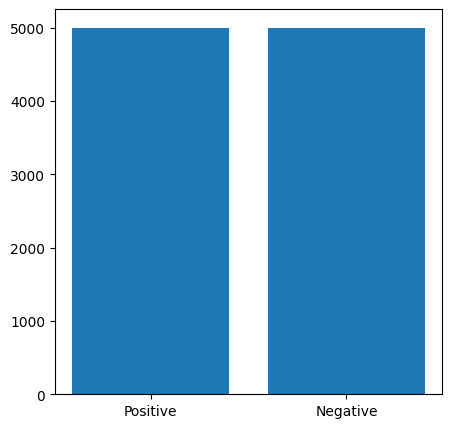

In [ ]:
fig = plt.figure(figsize=(5,5))

labels = 'Positive','Negative'

sizes = [tweets[tweets["Sentiment"]=="Positive"].value_counts().sum(),tweets[tweets["Sentiment"]=="Negative"].value_counts().sum()]

plt.bar(labels,sizes)

plt.show()


In [ ]:
tweet = positive_tweets.iloc[5]
print(tweet)

Tweets       @BhaktisBanter @PallaviRuhail This one is irre...
Sentiment                                             Positive
Name: 5, dtype: object


In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
tweet1=tweets["Tweets"][5059]
tweet1

'@mohsinmalvi19 @wishrajpoot @DrAzharAliKhan Nothing except lie, fraud, double cross, diplomacy, survival of fittest, zero tolerant..... :('

In [ ]:
tweet2 = re.sub(r'^RT[\s]+', '', tweet1)

tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

tweet2 = re.sub(r'#', '', tweet2)
tweet2 = re.sub(r'@', '', tweet2)

tweet2 = re.sub(r'[:)][:(]', '', tweet2)

print(tweet1)
print("\nCleaned tweet:\n", tweet2)

@mohsinmalvi19 @wishrajpoot @DrAzharAliKhan Nothing except lie, fraud, double cross, diplomacy, survival of fittest, zero tolerant..... :(

Cleaned tweet:
 mohsinmalvi19 wishrajpoot DrAzharAliKhan Nothing except lie, fraud, double cross, diplomacy, survival of fittest, zero tolerant..... 


In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,reduce_len=True)

tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenize string:\n')
print(tweet_tokens)


Tokenize string:

['mohsinmalvi', '19', 'wishrajpoot', 'drazharalikhan', 'nothing', 'except', 'lie', ',', 'fraud', ',', 'double', 'cross', ',', 'diplomacy', ',', 'survival', 'of', 'fittest', ',', 'zero', 'tolerant', '...']


In [ ]:
# Import the English stop words list from NLTK
from nltk.corpus import stopwords
import string

stopwords_english = stopwords.words('english')

print('Stop words:\n')
print(stopwords_english)

print('\nPunctuation:\n')
print(string.punctuation)

Stop words:

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [ ]:
# print()
# print('\033[92m')
print(tweet_tokens)
print()
# print('\033[94m')

tweets_clean = []

# Go through every word in your tokens list
for word in tweet_tokens:
    # Remove stopwords and punctuation
    if (word not in stopwords_english and
            word not in string.punctuation):
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)

['mohsinmalvi', '19', 'wishrajpoot', 'drazharalikhan', 'nothing', 'except', 'lie', ',', 'fraud', ',', 'double', 'cross', ',', 'diplomacy', ',', 'survival', 'of', 'fittest', ',', 'zero', 'tolerant', '...']

removed stop words and punctuation:
['mohsinmalvi', '19', 'wishrajpoot', 'drazharalikhan', 'nothing', 'except', 'lie', 'fraud', 'double', 'cross', 'diplomacy', 'survival', 'fittest', 'zero', 'tolerant', '...']


In [ ]:
def process_tweet(tweet):
    tokenizer = TweetTokenizer(
        preserve_case=False,
        strip_handles=True,
        reduce_len=True
    )

    # Remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)

    # Remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)

    # Remove the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)

    # Remove punctuation
    tweet = re.sub(r'@', '', tweet)
    tweet = re.sub(r'[^\w\s]', '', tweet)

    # Tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet)

    stopwords_english = stopwords.words('english')
    tweets_clean = []

    # Go through every word in your tokens list
    for word in tweet_tokens:
        # Remove stopwords and punctuation
        if (word not in stopwords_english and
                word not in string.punctuation):
            tweets_clean.append(word)

    return tweets_clean

In [ ]:
processed_tweets = all_tweets['Tweets'].apply(process_tweet)

all_tweets['Tweets_processed'] = processed_tweets

pd.set_option('display.max_colwidth', None)

all_tweets

,Tweets,Tweets_processed
0,hopeless for tmr :(,"[hopeless, tmr]"
1,Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(,"[everything, kids, section, ikea, cute, shame, im, nearly, 19, 2, months]"
2,@Hegelbon That heart sliding into the waste basket. :(,"[hegelbon, heart, sliding, waste, basket]"
3,"“@ketchBurning: I hate Japanese call him ""bani"" :( :(”\n\nMe too","[ketchburning, hate, japanese, call, bani]"
4,"Dang starting next week I have ""work"" :(","[dang, starting, next, week, work]"
...,...,...
29995,"RT @UKLabour: .@Ed_Miliband: we're not going to do a deal with the SNP, there will be no coalition with the SNP. #bbcqt\nhttps://t.co/n65hTe…","[uklabour, ed_miliband, going, deal, snp, coalition, snp, bbcqt]"
29996,"RT @DisabledScot: @blairmcdougall @ScotlandTonight @bbcqt If Ed thinks Scots will suddenly rush to vote Labour, we'll vote SNP, Labour just…","[disabledscot, blairmcdougall, scotlandtonight, bbcqt, ed, thinks, scots, suddenly, rush, vote, labour, well, vote, snp, labour]"
29997,RT @Staircase2: @VividRicky exactly but that alleged commute was made up by Farage as was his 'discomfort' in allegedly 'not hearing Englis…,"[staircase, 2, vividricky, exactly, alleged, commute, made, farage, discomfort, allegedly, hearing, englis]"
29998,Actually agreed with %95 of what farage was sayin rhen#voteukip,"[actually, agreed, 95, farage, sayin, rhenvoteukip]"
